# Load Data

In [6]:
import sys, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from src.preprocessing import full_preprocessing_pipeline
from src.features import prepare_all, add_engineered_features
from src.models import get_baseline_models
from src.evaluation import (
    run_all_models, 
    show_comparison_table,
    plot_comparison, 
    plot_confusion_matrices,
    plot_roc_curves, 
    save_model,
)


# Load Data

In [7]:
# membuat file model
os.makedirs('../models', exist_ok=True)

# membaca data setekah preprocessing
df = full_preprocessing_pipeline('D:\Dibimbing.Id\Supply Chain\dataset\DataCoSupplyChainDataset.csv')
df = add_engineered_features(df)
print(f"Dataset: {df.shape}")

Dataset berjumlah 180519 baris dan 53 kolom
Kolom yang telah dihapus (22): ['Delivery Status', 'shipping date (DateOrders)', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Street', 'Customer Id', 'Order Customer Id', 'Order Id', 'Order Item Id', 'Order Item Cardprod Id', 'Product Card Id', 'Product Category Id', 'Category Id', 'Department Id', 'Product Image', 'Customer Zipcode', 'Latitude', 'Longitude', 'Product Description', 'Order Zipcode']
Tidak ada missing values.

Kolom yang memiliki missing value lebih dari 50%: []
Jumlah kolom sebelum didrop: 31
Jumlah kolom setelah didrop: 31
Tidak ada data yang duplicates.
Fitur redundan yang didrop: ['Order Profit Per Order', 'Order Item Product Price', 'Order Item Total']
Kolom kategorik yang didrop (10): ['Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'Market', 'Order City', 'Order State', 'order date (DateOrders)', 'Order Status', 'Order Country']
Kolom konstan di-drop: ['

In [8]:
# encode dan split data
data = prepare_all(
    df,
    scaler_s1_path='../models/scaler_s1.pkl',
    scaler_s2_path='../models/scaler_s2.pkl',
)


Fitur baru ditambahkan: discount_per_unit
OHE cols: ['Type']
Dtypes sebelum OHE: Type    str
dtype: object
OHE cols: ['Type', 'Order Region', 'Customer State']
Dtypes sebelum OHE: Type              str
Order Region      str
Customer State    str
dtype: object
Skenario 1 setelah encoding: (180519, 9)
Skenario 2 setelah encoding: (180519, 78)

--- Skenario 1 (Pre-Shipment) ---
Train: 144,415 | Test: 36,104 | Fitur: 8

--- Skenario 2 (Full Order Profile) ---
Train: 144,415 | Test: 36,104 | Fitur: 77


# Skenario 1 - Pre Shipment

In [10]:
models = get_baseline_models()
results_s1 = run_all_models(
    models, X_train_s1, X_test_s1, y_train_s1, y_test_s1,
    label='Skenario 1 - Pre-Shipment'
)



MODELLING — Skenario 1 - Pre-Shipment
Train: 144,415 | Test: 36,104 | Fitur: 8
  Training Logistic Regression... F1=0.6767 | AUC=0.7239 (3.25s)
  Training Decision Tree... F1=0.6551 | AUC=0.7076 (0.45s)
  Training Random Forest... F1=0.6645 | AUC=0.7181 (2.12s)
  Training Extra Trees... F1=0.6576 | AUC=0.7125 (1.85s)
  Training XGBoost... F1=0.6679 | AUC=0.7376 (0.73s)
  Training LightGBM... F1=0.6655 | AUC=0.7407 (3.6s)
  Training CatBoost... F1=0.6682 | AUC=0.7387 (27.21s)
  Training MLP... F1=0.6758 | AUC=0.7432 (255.72s)


In [11]:
df_res_s1 = show_comparison_table(results_s1, 'Skenario 1 - Pre-Shipment')



--- Tabel Perbandingan [Skenario 1 - Pre-Shipment] ---
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
1  Logistic Regression    0.6919     0.7968  0.5880    0.6767   0.7239            3.25
2                  MLP    0.6941     0.8066  0.5816    0.6758   0.7432          255.72
3             CatBoost    0.6960     0.8320  0.5582    0.6682   0.7387           27.21
4              XGBoost    0.6941     0.8248  0.5612    0.6679   0.7376            0.73
5             LightGBM    0.6970     0.8430  0.5498    0.6655   0.7407            3.60
6        Random Forest    0.6748     0.7650  0.5874    0.6645   0.7181            2.12
7          Extra Trees    0.6744     0.7766  0.5702    0.6576   0.7125            1.85
8        Decision Tree    0.6728     0.7760  0.5668    0.6551   0.7076            0.45

Model terbaik: Logistic Regression (F1=0.6767)


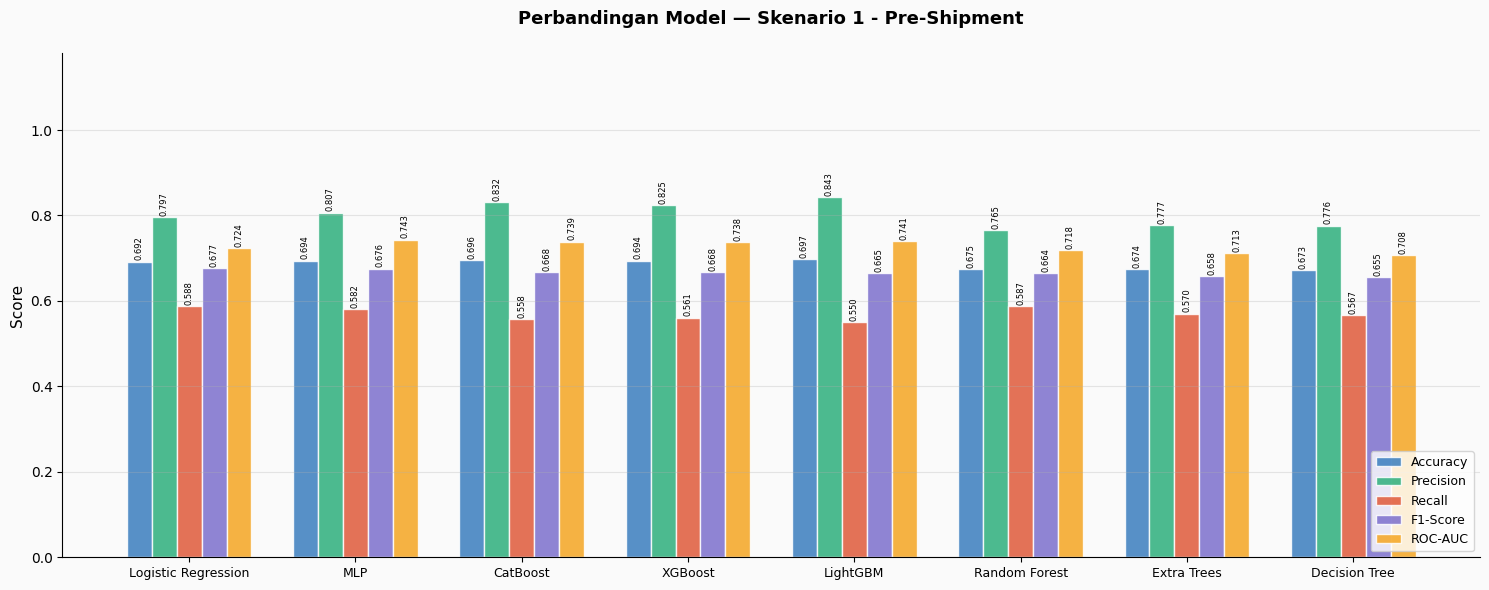

In [12]:
plot_comparison(df_res_s1, 'Skenario 1 - Pre-Shipment')

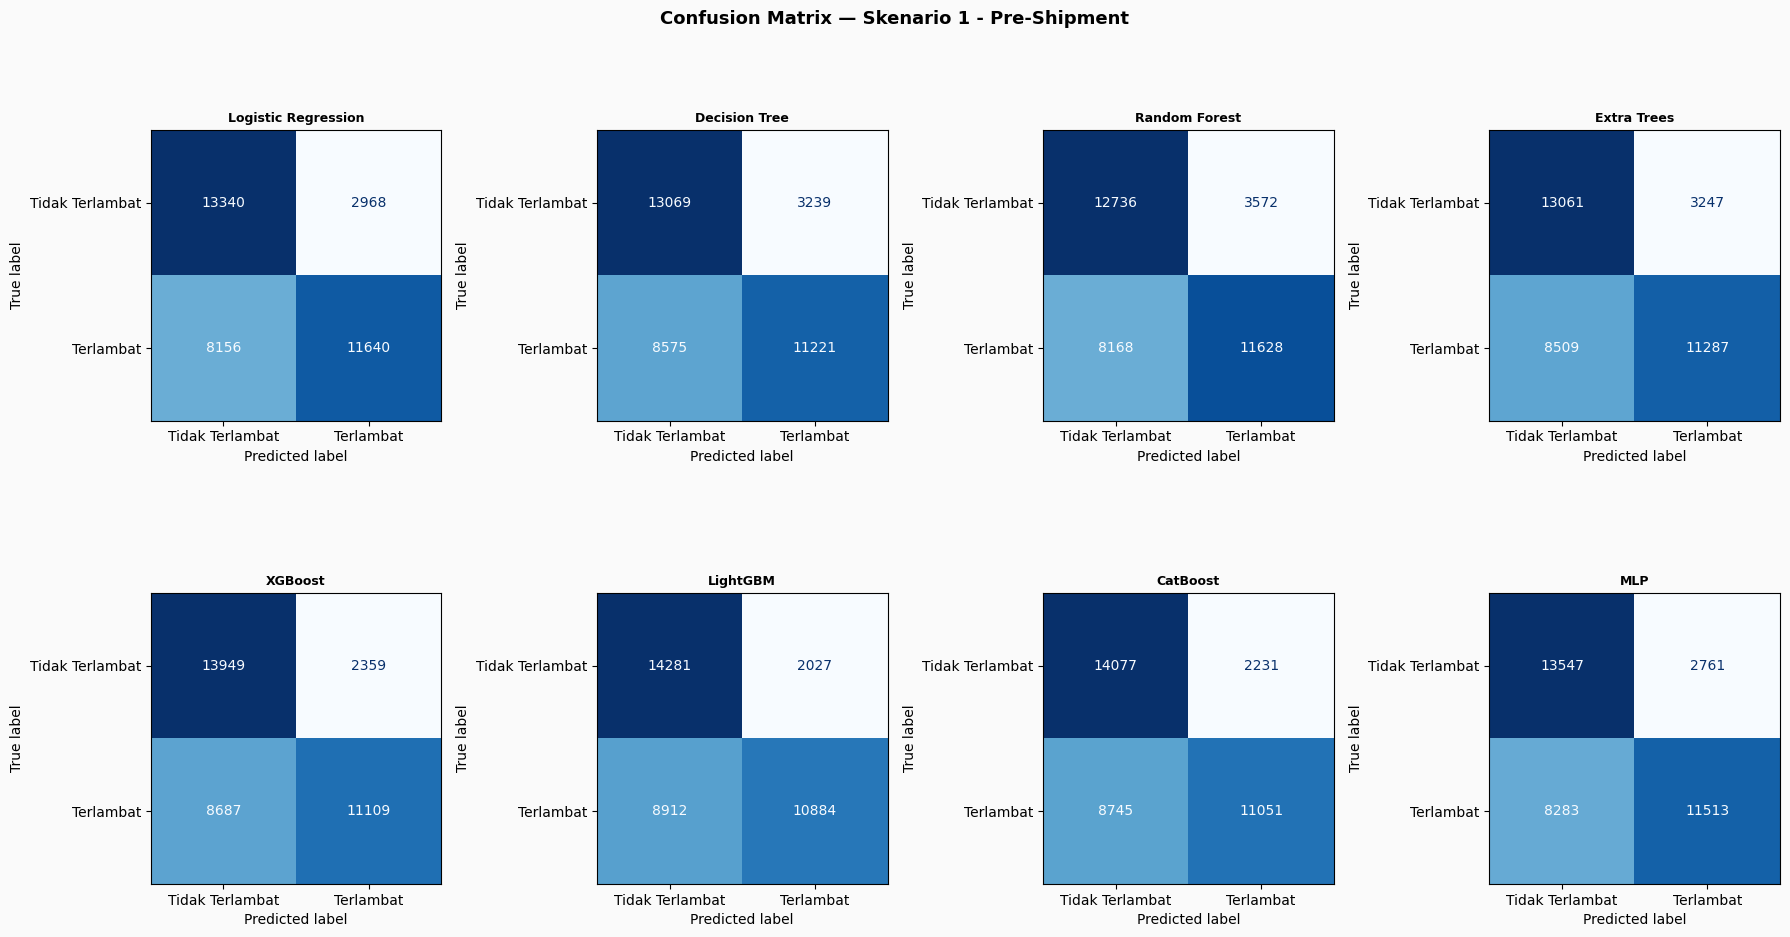

In [13]:
plot_confusion_matrices(results_s1, y_test_s1, 'Skenario 1 - Pre-Shipment')

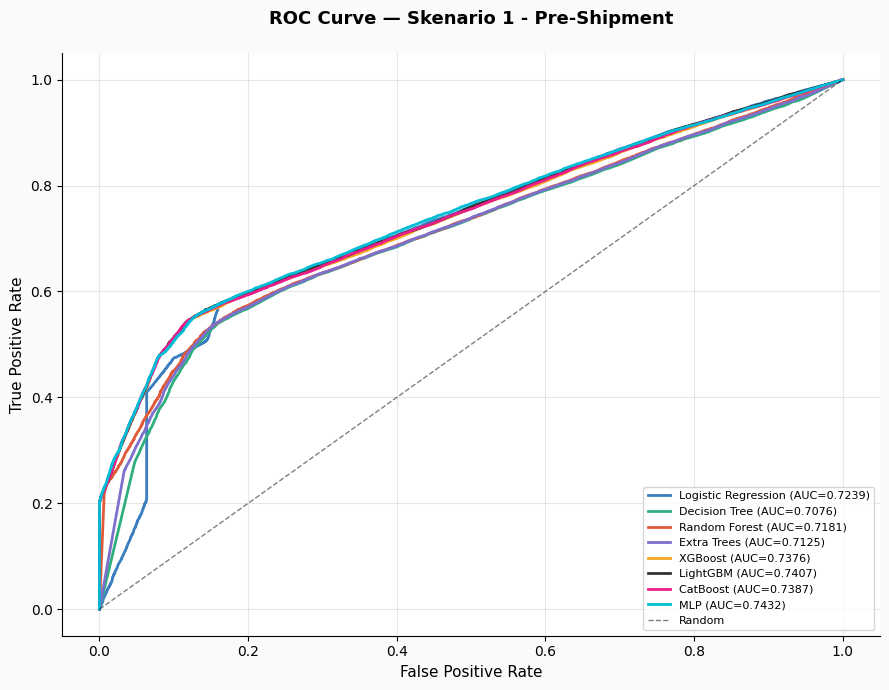

In [14]:
plot_roc_curves(results_s1, y_test_s1, 'Skenario 1 - Pre-Shipment')


In [15]:
from sklearn.metrics import classification_report
best_s1_name = df_res_s1.iloc[0]['Model']
best_res_s1  = next(r for r in results_s1 if r['Model'] == best_s1_name)
print(f"Classification Report — {best_s1_name} (Skenario 1)")
print(classification_report(y_test_s1, best_res_s1['_y_pred'],
      target_names=['Tidak Terlambat','Terlambat']))


Classification Report — Logistic Regression (Skenario 1)
                 precision    recall  f1-score   support

Tidak Terlambat       0.62      0.82      0.71     16308
      Terlambat       0.80      0.59      0.68     19796

       accuracy                           0.69     36104
      macro avg       0.71      0.70      0.69     36104
   weighted avg       0.72      0.69      0.69     36104



# Skenario 2 - Full Order Profile

In [16]:
models = get_baseline_models()
results_s2 = run_all_models(
    models, X_train_s2, X_test_s2, y_train_s2, y_test_s2,
    label='Skenario 2 - Full Order Profile'
)


MODELLING — Skenario 2 - Full Order Profile
Train: 144,415 | Test: 36,104 | Fitur: 77
  Training Logistic Regression... F1=0.6766 | AUC=0.7237 (49.75s)
  Training Decision Tree... F1=0.6597 | AUC=0.6202 (5.63s)
  Training Random Forest... F1=0.6958 | AUC=0.7517 (6.04s)
  Training Extra Trees... F1=0.7014 | AUC=0.7469 (8.91s)
  Training XGBoost... F1=0.6786 | AUC=0.7504 (1.47s)
  Training LightGBM... F1=0.6716 | AUC=0.7523 (0.82s)
  Training CatBoost... F1=0.6812 | AUC=0.7582 (28.13s)
  Training MLP... F1=0.6807 | AUC=0.7459 (913.32s)


In [17]:
df_res_s2 = show_comparison_table(results_s2, 'Skenario 2 - Full Order Profile')


--- Tabel Perbandingan [Skenario 2 - Full Order Profile] ---
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
1          Extra Trees    0.6796     0.7172  0.6862    0.7014   0.7469            8.91
2        Random Forest    0.6846     0.7383  0.6579    0.6958   0.7517            6.04
3             CatBoost    0.7020     0.8238  0.5806    0.6812   0.7582           28.13
4                  MLP    0.6949     0.7987  0.5931    0.6807   0.7459          913.32
5              XGBoost    0.6982     0.8154  0.5811    0.6786   0.7504            1.47
6  Logistic Regression    0.6919     0.7968  0.5880    0.6766   0.7237           49.75
7             LightGBM    0.6991     0.8363  0.5611    0.6716   0.7523            0.82
8        Decision Tree    0.6244     0.6555  0.6639    0.6597   0.6202            5.63

Model terbaik: Extra Trees (F1=0.7014)


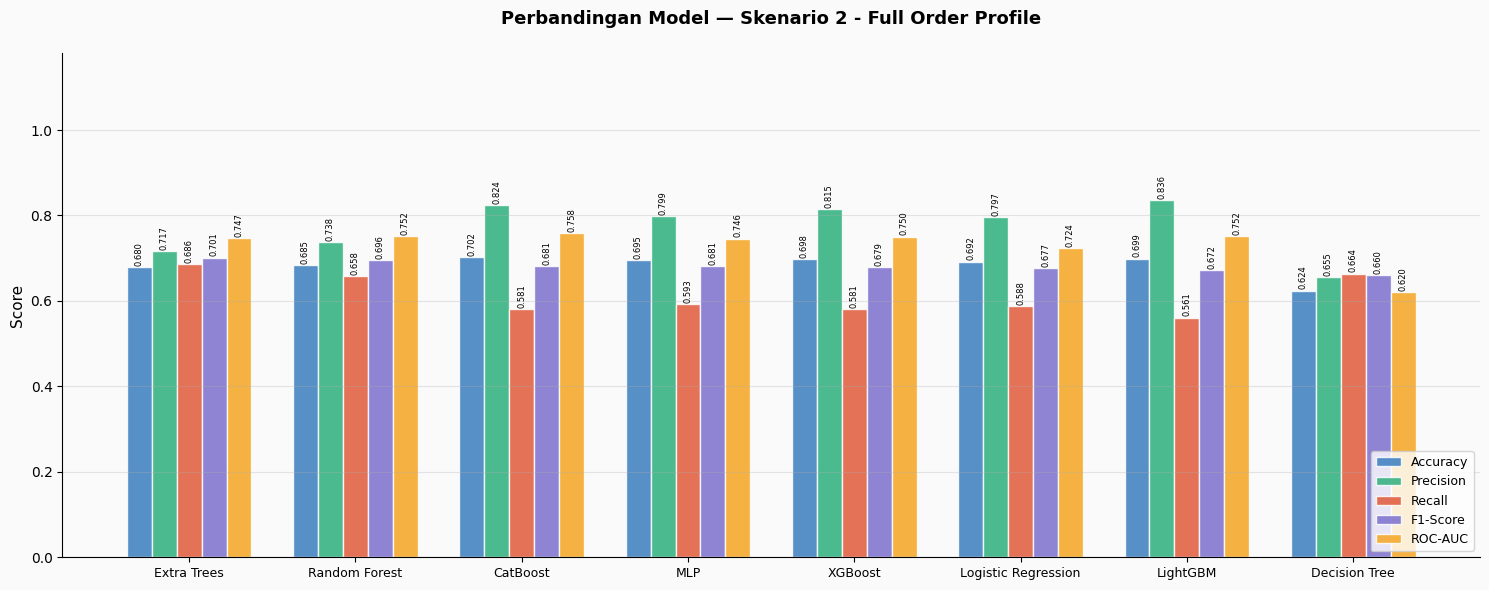

In [18]:
plot_comparison(df_res_s2, 'Skenario 2 - Full Order Profile')

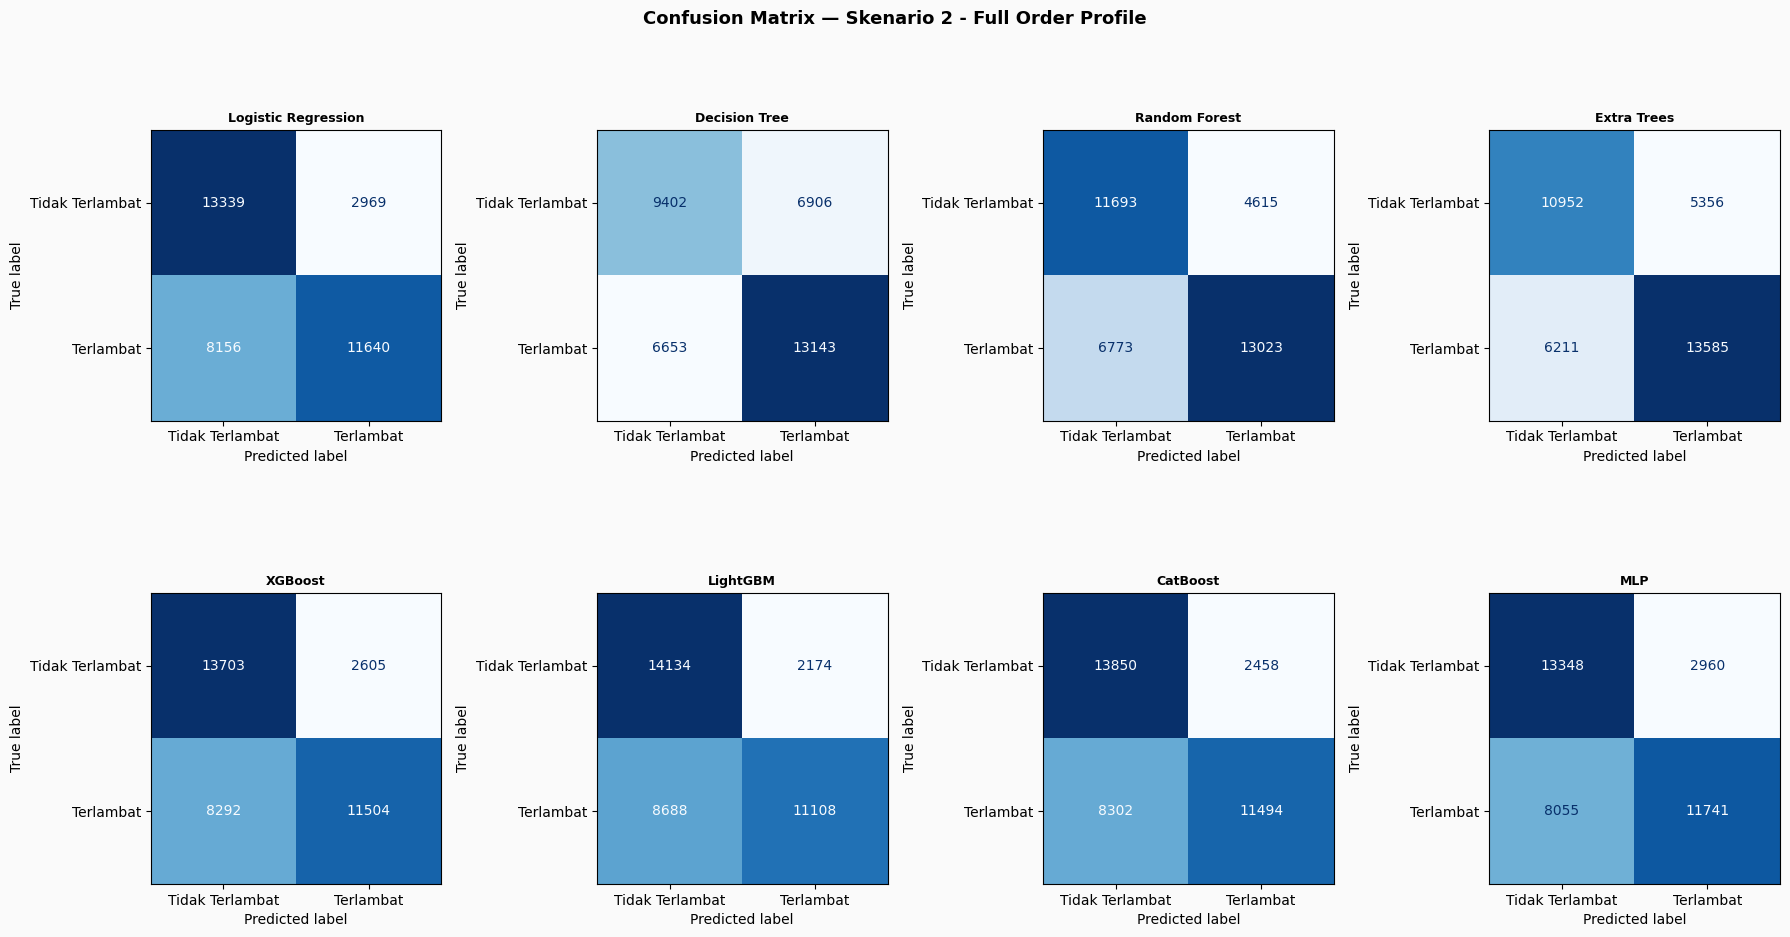

In [19]:
plot_confusion_matrices(results_s2, y_test_s2, 'Skenario 2 - Full Order Profile')

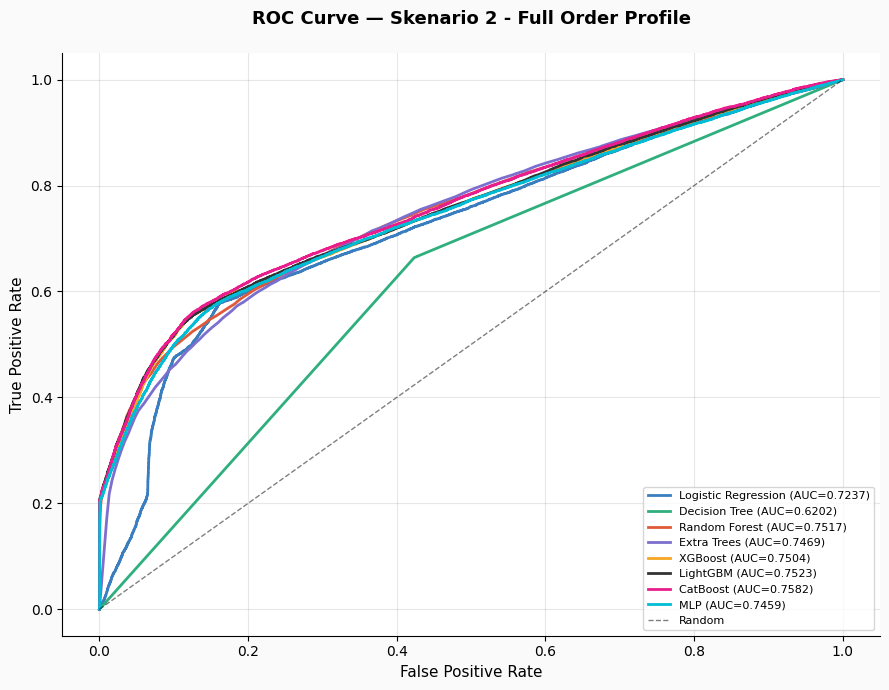

In [20]:
plot_roc_curves(results_s2, y_test_s2, 'Skenario 2 - Full Order Profile')

In [21]:
best_s2_name = df_res_s2.iloc[0]['Model']
best_res_s2  = next(r for r in results_s2 if r['Model'] == best_s2_name)
print(f"Classification Report — {best_s2_name} (Skenario 2)")
print(classification_report(y_test_s2, best_res_s2['_y_pred'],
      target_names=['Tidak Terlambat','Terlambat']))

Classification Report — Extra Trees (Skenario 2)
                 precision    recall  f1-score   support

Tidak Terlambat       0.64      0.67      0.65     16308
      Terlambat       0.72      0.69      0.70     19796

       accuracy                           0.68     36104
      macro avg       0.68      0.68      0.68     36104
   weighted avg       0.68      0.68      0.68     36104



# Perbandingan 2 Skenario

In [22]:
metrics_show = ['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']
df_s1_show = pd.DataFrame([{k: r[k] for k in metrics_show} for r in results_s1])
df_s2_show = pd.DataFrame([{k: r[k] for k in metrics_show} for r in results_s2])

pivot = df_s1_show.set_index('Model')[['F1-Score']].rename(columns={'F1-Score':'S1_F1'})
pivot['S2_F1'] = df_s2_show.set_index('Model')['F1-Score']
pivot['Δ(S2-S1)'] = (pivot['S2_F1'] - pivot['S1_F1']).round(4)
print("=== Perbandingan F1-Score Antar Skenario ===")
print(pivot.sort_values('S2_F1', ascending=False).to_string())


=== Perbandingan F1-Score Antar Skenario ===
                      S1_F1   S2_F1  Δ(S2-S1)
Model                                        
Extra Trees          0.6576  0.7014    0.0438
Random Forest        0.6645  0.6958    0.0313
CatBoost             0.6682  0.6812    0.0130
MLP                  0.6758  0.6807    0.0049
XGBoost              0.6679  0.6786    0.0107
Logistic Regression  0.6767  0.6766   -0.0001
LightGBM             0.6655  0.6716    0.0061
Decision Tree        0.6551  0.6597    0.0046


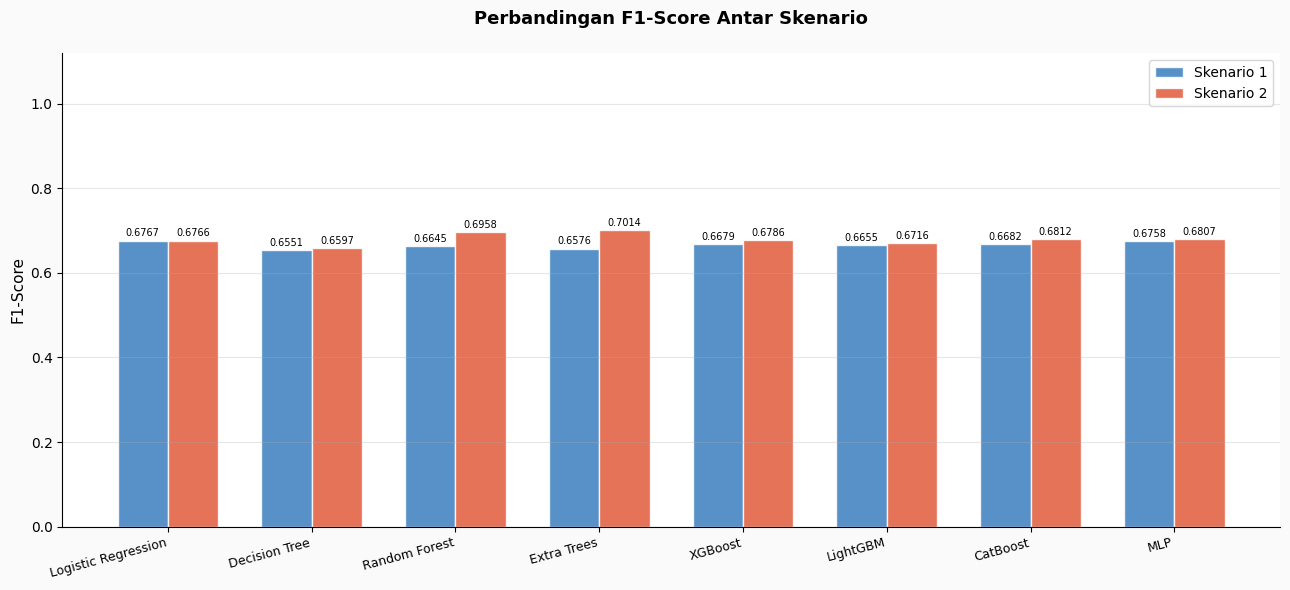

In [23]:
models_list = df_s1_show['Model'].tolist()
x = np.arange(len(models_list)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#FAFAFA')
f1_s1 = df_s1_show.set_index('Model')['F1-Score']
f1_s2 = df_s2_show.set_index('Model')['F1-Score']
bars1 = ax.bar(x - w/2, [f1_s1[m] for m in models_list], w,
               label='Skenario 1', color='#3A7EBF', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, [f1_s2[m] for m in models_list], w,
               label='Skenario 2', color='#E05A3A', alpha=0.85, edgecolor='white')
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(models_list, fontsize=9, rotation=15, ha='right')
ax.set_ylim(0, 1.12); ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('Perbandingan F1-Score Antar Skenario\n', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


In [24]:
best_model_s1 = next(r['_model'] for r in results_s1 if r['Model'] == best_s1_name)
best_model_s2 = next(r['_model'] for r in results_s2 if r['Model'] == best_s2_name)

save_model(best_model_s1, '../models/baseline_best_s1.pkl')
save_model(best_model_s2, '../models/baseline_best_s2.pkl')

# Simpan hasil untuk dipakai di notebook tuning
import pickle
with open('../models/_results_baseline.pkl', 'wb') as f:
    pickle.dump({'s1': results_s1, 's2': results_s2,
                 'df_s1': df_res_s1, 'df_s2': df_res_s2,
                 'data': {k: {kk: vv for kk, vv in v.items() if kk != 'scaler'}
                          for k, v in data.items()}}, f)
print("tersimpan di folder models/")


Model disimpan: ../models/baseline_best_s1.pkl
Model disimpan: ../models/baseline_best_s2.pkl
tersimpan di folder models/
